# Sales Data Analysis Project

This project analyzes retail sales data to identify trends,
top-performing products, and regional performance using Python and SQL.

Tools Used:
- Python
- Pandas
- SQL
- Matplotlib

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [45]:
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [7]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [10]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

In [11]:
df = df.drop_duplicates()

In [12]:
conn = sqlite3.connect("sales.db")
df.to_sql("sales", conn, if_exists="replace", index=False)

9994

In [13]:
query = """
SELECT SUM(Sales) AS total_revenue
FROM sales
"""
pd.read_sql(query, conn)

,total_revenue
0,2.297201e+06


In [14]:
query = """
SELECT Category, SUM(Sales) AS total_sales
FROM sales
GROUP BY Category
ORDER BY total_sales DESC
"""
pd.read_sql(query, conn)

,Category,total_sales
0,Technology,836154.0330
1,Furniture,741999.7953
2,Office Supplies,719047.0320


In [15]:
query = """
SELECT Region, SUM(Sales) AS regional_sales
FROM sales
GROUP BY Region
ORDER BY regional_sales DESC
"""
pd.read_sql(query, conn)

,Region,regional_sales
0,West,725457.8245
1,East,678781.2400
2,Central,501239.8908
3,South,391721.9050


In [16]:
query = """
SELECT "Sub-Category", SUM(Sales) AS total_sales
FROM sales
GROUP BY "Sub-Category"
ORDER BY total_sales DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,Sub-Category,total_sales
0,Phones,330007.0540
1,Chairs,328449.1030
2,Storage,223843.6080
3,Tables,206965.5320
4,Binders,203412.7330
5,Machines,189238.6310
6,Accessories,167380.3180
7,Copiers,149528.0300
8,Bookcases,114879.9963
9,Appliances,107532.1610


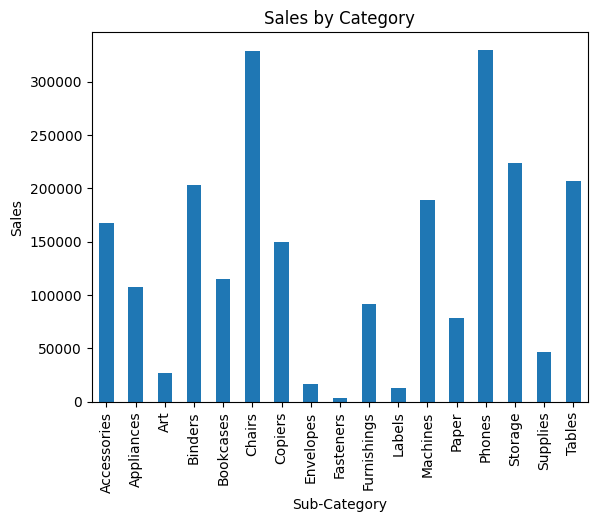

In [48]:
df.groupby("Category")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

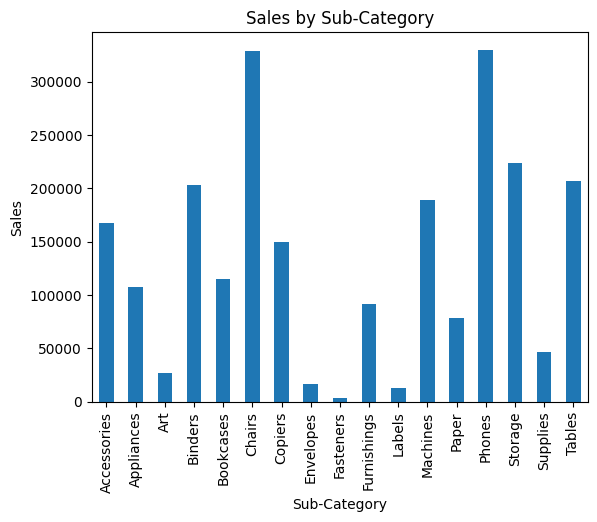

In [49]:
df.groupby("Sub-Category")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Sub-Category")
plt.ylabel("Sales")
plt.show()

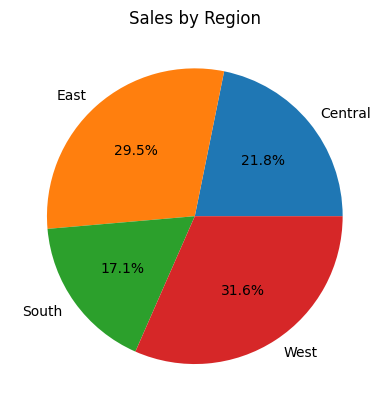

In [52]:
df.groupby("Region")["Sales"].sum().plot(kind="pie", autopct='%1.1f%%')
plt.title("Sales by Region")
plt.show()

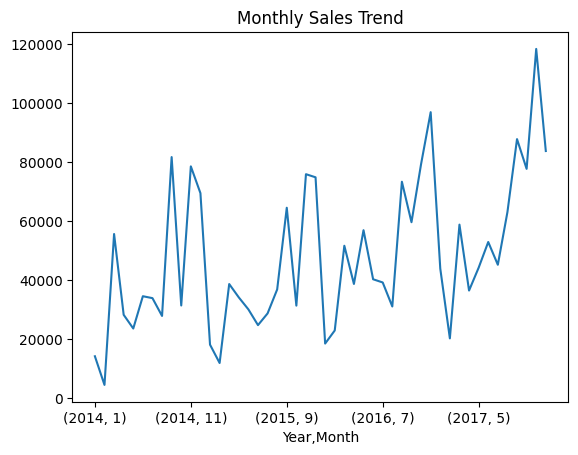

In [19]:
monthly_sales = df.groupby(["Year","Month"])["Sales"].sum()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()

## Key Insights

• Technology category generates the highest revenue  
• West region has the highest sales  
• Sales peak during holiday months  

In [31]:

# Customer Purchasing Behavior Analysis - SQL Queries

# 1. Customer Purchase Frequency and Total Spending
query1 = """
SELECT 
    "Customer ID",
    "Customer Name",
    COUNT(*) AS purchase_count,
    SUM(Sales) AS total_spending,
    AVG(Sales) AS avg_order_value,
    SUM(Profit) AS total_profit
FROM sales
GROUP BY "Customer ID", "Customer Name"
ORDER BY total_spending DESC
LIMIT 15;
"""

print("=== Top 15 Customers by Total Spending ===")
print(pd.read_sql(query1, conn))


=== Top 15 Customers by Total Spending ===
   Customer ID       Customer Name  purchase_count  total_spending  \
0     SM-20320         Sean Miller              15       25043.050   
1     TC-20980        Tamara Chand              12       19052.218   
2     RB-19360        Raymond Buch              18       15117.339   
3     TA-21385        Tom Ashbrook              10       14595.620   
4     AB-10105       Adrian Barton              20       14473.571   
5     KL-16645        Ken Lonsdale              29       14175.229   
6     SC-20095        Sanjit Chand              22       14142.334   
7     HL-15040        Hunter Lopez              11       12873.298   
8     SE-20110        Sanjit Engle              19       12209.438   
9     CC-12370  Christopher Conant              11       12129.072   
10    TS-21370        Todd Sumrall              15       11891.751   
11    GT-14710           Greg Tran              29       11820.120   
12    BM-11140        Becky Martin             

In [36]:

# 2. Customer Loyalty - Repeat Purchase Analysis
query2 = """
SELECT 
    "Customer ID",
    "Customer Name",
    COUNT(DISTINCT "Order ID") AS distinct_orders,
    COUNT(*) AS total_line_items,
    MIN("Order Date") AS first_purchase,
    MAX("Order Date") AS last_purchase,
    ROUND(100.0 * SUM(Profit) / SUM(Sales), 2) AS avg_profit_margin
FROM sales
GROUP BY "Customer ID", "Customer Name"
HAVING COUNT(DISTINCT "Order ID") >= 3
ORDER BY distinct_orders DESC
LIMIT 20;
"""

print("\n=== Repeat Customers (3+ Orders) ===")
print(pd.read_sql(query2, conn))



=== Repeat Customers (3+ Orders) ===
   Customer ID        Customer Name  distinct_orders  total_line_items  \
0     EP-13915           Emily Phan               17                31   
1     CK-12205  Chloris Kastensmidt               13                32   
2     EA-14035        Erin Ashbrook               13                25   
3     JE-15745           Joel Eaton               13                23   
4     NS-18640         Noel Staavos               13                26   
5     PG-18820      Patrick Gardner               13                26   
6     SH-19975        Sally Hughsby               13                29   
7     ZC-21910     Zuschuss Carroll               13                31   
8     AH-10690        Anna Häberlin               12                23   
9     BD-11320       Bill Donatelli               12                19   
10    BP-11095         Bart Pistole               12                20   
11    CC-12220         Chris Cortes               12                22   


In [37]:

# 3. Product Category Preferences by Customer Segment
query3 = """
SELECT 
    Segment,
    Category,
    COUNT(*) AS purchase_count,
    SUM(Sales) AS total_sales,
    ROUND(100.0 * SUM(Sales) / 
        (SELECT SUM(Sales) FROM sales s2 WHERE s2.Segment = sales.Segment), 2) 
        AS pct_of_segment
FROM sales
GROUP BY Segment, Category
ORDER BY Segment, total_sales DESC;
"""

print("\n=== Product Category Preferences by Segment ===")
print(pd.read_sql(query3, conn))



=== Product Category Preferences by Segment ===
       Segment         Category  purchase_count  total_sales  pct_of_segment
0     Consumer       Technology             951  406399.8970           34.99
1     Consumer        Furniture            1113  391049.3120           33.67
2     Consumer  Office Supplies            3127  363952.1360           31.34
3    Corporate       Technology             554  246450.1190           34.90
4    Corporate  Office Supplies            1820  230676.4620           32.67
5    Corporate        Furniture             646  229019.7858           32.43
6  Home Office       Technology             342  183304.0170           42.66
7  Home Office  Office Supplies            1079  124418.4340           28.96
8  Home Office        Furniture             362  121930.6975           28.38


In [38]:

# 4. High-Risk Customers (Negative Profit)
query4 = """
SELECT 
    "Customer ID",
    "Customer Name",
    Segment,
    COUNT(*) AS order_count,
    SUM(Sales) AS total_sales,
    SUM(Profit) AS total_profit,
    ROUND(100.0 * SUM(Profit) / SUM(Sales), 2) AS profit_margin,
    AVG(Discount) AS avg_discount_applied
FROM sales
GROUP BY "Customer ID", "Customer Name", Segment
HAVING SUM(Profit) < 0
ORDER BY SUM(Profit) ASC;
"""

print("\n=== Unprofitable Customers (Negative Profit) ===")
print(pd.read_sql(query4, conn))



=== Unprofitable Customers (Negative Profit) ===
    Customer ID    Customer Name      Segment  order_count  total_sales  \
0      CS-12505    Cindy Stewart     Consumer            9     5690.055   
1      GT-14635   Grant Thornton    Corporate            6     9351.212   
2      LF-17185      Luke Foster     Consumer           16     3930.509   
3      SR-20425   Sharelle Roach  Home Office            9     3233.481   
4      HG-14965    Henry Goldwyn    Corporate           17     3247.642   
..          ...              ...          ...          ...          ...   
150    TS-21085    Thais Sissman     Consumer            2        4.833   
151    AH-10120      Adrian Hane  Home Office           16     1735.514   
152    MG-18205  Mitch Gastineau    Corporate            2       16.739   
153    PL-18925       Paul Lucas  Home Office            8      239.481   
154    JC-15340  Jasper Cacioppo     Consumer            4       71.263   

     total_profit  profit_margin  avg_discount_ap

In [35]:

# 5. Average Customer Lifetime Value by Region
query5 = """
SELECT 
    Region,
    COUNT(DISTINCT "Customer ID") AS num_customers,
    ROUND(AVG(customer_sales), 2) AS avg_customer_lifetime_value,
    ROUND(MAX(customer_sales), 2) AS max_customer_value,
    ROUND(MIN(customer_sales), 2) AS min_customer_value
FROM (
    SELECT 
        Region,
        "Customer ID",
        SUM(Sales) AS customer_sales
    FROM sales
    GROUP BY Region, "Customer ID"
)
GROUP BY Region
ORDER BY avg_customer_lifetime_value DESC;
"""

print("\n=== Customer Lifetime Value by Region ===")
print(pd.read_sql(query5, conn))



=== Customer Lifetime Value by Region ===
    Region  num_customers  avg_customer_lifetime_value  max_customer_value  \
0     West            686                      1057.52            14345.28   
1     East            674                      1007.09            13723.50   
2  Central            629                       796.88            18437.14   
3    South            512                       765.08            23669.20   

   min_customer_value  
0                2.02  
1                0.85  
2                0.56  
3                1.17  
